# **Social Media Engagement Analysis Using Python**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving social_media_engagement_5000.csv to social_media_engagement_5000.csv


#**Task 1-Data Import & Setup**

In [ ]:
# Task 1: Import Libraries & Load Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px





In [ ]:
# Load Dataset
df = pd.read_csv("social_media_engagement_5000.csv")

In [ ]:
# Display First Records
print(df.head())

   user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  Female  Brazil   496713     image       fitness   7011.0   
1    10860  33.0    Male  Brazil   157326      reel          food  11750.0   
2    86820  32.0  Female      UK   109864      text          food   4862.0   
3    64886  51.0   Other  France   848877      text       fitness   5350.0   
4    16265  34.0   Other      UK   449706     image       fitness  12682.0   

   comments  shares  watch_time_sec  impression_count   posted_at  \
0     354.0  1157.0            5726             44650  17-12-2022   
1    2606.0  1807.0            5947             80216  02-06-2023   
2     344.0   955.0            6946             44858  07-05-2023   
3    1083.0  1049.0             229             70455  12-02-2023   
4    2735.0  1300.0            4798              6019  23-05-2023   

   follower_count  is_verified device_type sentiment               hashtags  \
0           81734        False      m

In [ ]:
# Dataset Information
print(df.info())
print(df.shape)
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


#**Task 2- Data Cleaning**

In [ ]:
# Task 2: Data Cleaning
# Check Missing Values
print(df.isnull().sum())


user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


In [ ]:
# Fill Numeric Missing Values with Median
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_1332/4171900497.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
# Fill Categorical Missing Values with Mode
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_1332/3404849161.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
# Remove Duplicates
df.drop_duplicates(inplace=True)

In [ ]:
# Convert Date Column
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])

In [ ]:
# Standardize Text Columns
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

In [ ]:
# Remove Negative Values
for col in ['likes','comments','shares','impressions']:
    if col in df.columns:
        df[col] = df[col].abs()

# **Task 3-Data Exploration using Pandas**



In [ ]:
# Task 3: Feature Engineering

# Engagement Score
if all(col in df.columns for col in ['likes','comments','shares']):
    df['engagement_score'] = (
        df['likes'] +
        df['comments']*2 +
        df['shares']*3
    )


In [ ]:
# Hashtag Count
if 'hashtags' in df.columns:
    df['hashtag_count'] = df['hashtags'].astype(str).apply(
        lambda x: len(x.split())
    )

#**Task 4-Data Wrangling**

In [ ]:
# Task 4: Data Exploration

print("\nSummary Statistics")
print(df.describe())



Summary Statistics
            user_id          age        post_id         likes     comments  \
count   5000.000000  5000.000000    5000.000000   5000.000000  5000.000000   
mean   54561.890800    38.440400  548042.909000  10106.997400  1502.039800   
std    26090.370121    14.687151  260646.957267   5702.293017   856.393312   
min    10055.000000    13.000000  100068.000000     10.000000     0.000000   
25%    32309.500000    26.000000  322543.500000   5235.000000   792.000000   
50%    54374.500000    38.000000  548077.500000  10105.500000  1497.000000   
75%    77180.500000    51.000000  771574.500000  14959.000000  2235.250000   
max    99963.000000    64.000000  999455.000000  19998.000000  2999.000000   

          shares  watch_time_sec  impression_count  follower_count  \
count  5000.0000     5000.000000       5000.000000     5000.000000   
mean   1002.9106     4014.503200      50013.732800   393698.224800   
std     570.8552     2308.096459      28844.939104   230927.884535 

In [ ]:
# Unique Values
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


gender
gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64

country
country
India        535
Canada       513
Brazil       504
Uae          503
Usa          501
France       496
Uk           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64

post_type
post_type
Reel     1283
Image    1247
Text     1245
Video    1225
Name: count, dtype: int64

post_category
post_category
Fitness      675
Tech         665
Music        635
Education    631
Lifestyle    607
Travel       600
Fashion      594
Food         593
Name: count, dtype: int64

posted_at
posted_at
26-12-2023    16
28-06-2023    16
05-08-2022    16
26-11-2023    15
17-08-2022    15
              ..
10-08-2022     2
08-11-2022     2
10-08-2023     2
06-09-2023     1
20-12-2022     1
Name: count, Length: 729, dtype: int64

device_type
device_type
Mobile     1684
Tablet     1658
Desktop    1658
Name: count, dtype: int64

sentiment
sentiment
Positive    2513
Neutral     1527
Negati

In [ ]:
# Correlation Matrix
corr_matrix = df.select_dtypes(include=np.number).corr()
print(corr_matrix)

                   user_id       age   post_id     likes  comments    shares  \
user_id           1.000000 -0.006688  0.020051  0.025811 -0.033395  0.013763   
age              -0.006688  1.000000 -0.013153 -0.036322 -0.007284  0.013871   
post_id           0.020051 -0.013153  1.000000  0.014526 -0.010540  0.001846   
likes             0.025811 -0.036322  0.014526  1.000000 -0.018421  0.004712   
comments         -0.033395 -0.007284 -0.010540 -0.018421  1.000000  0.006142   
shares            0.013763  0.013871  0.001846  0.004712  0.006142  1.000000   
watch_time_sec   -0.016847  0.005542  0.018374  0.008710 -0.016351  0.014658   
impression_count  0.015326  0.013322 -0.007709  0.007952 -0.009395 -0.005204   
follower_count    0.010124 -0.024894 -0.002844 -0.022982 -0.011733 -0.010783   
engagement_rate  -0.004282  0.008039  0.010139  0.093520  0.000051  0.021724   
engagement_score  0.018385 -0.031707  0.011000  0.919401  0.261998  0.283318   
hashtag_count    -0.013692  0.007173  0.

In [ ]:
# GroupBy Analysis
if 'post_type' in df.columns and 'likes' in df.columns:
    print(df.groupby('post_type')['likes'].mean())

if 'country' in df.columns and 'impressions' in df.columns:
    print(df.groupby('country')['impressions'].mean())

post_type
Image    10104.865277
Reel     10037.802416
Text     10100.148193
Video    10188.600000
Name: likes, dtype: float64


#**Task 5-Statistical Analysis**

In [ ]:
# Task 5: Statistical Analysis

stats_cols = ['likes','comments','shares',
              'watch_time','engagement_rate',
              'followers']

stats_cols = [col for col in stats_cols if col in df.columns]

for col in stats_cols:

    print("\n", "="*50)
    print("Column:", col)

    print("Mean :", df[col].mean())
    print("Median :", df[col].median())
    print("Mode :", df[col].mode()[0])
    print("Std :", df[col].std())
    print("Variance :", df[col].var())

    print("25 Percentile :", df[col].quantile(0.25))
    print("50 Percentile :", df[col].quantile(0.50))
    print("75 Percentile :", df[col].quantile(0.75))


Column: likes
Mean : 10106.9974
Median : 10105.5
Mode : 10105.5
Std : 5702.293017183876
Variance : 32516145.653823998
25 Percentile : 5235.0
50 Percentile : 10105.5
75 Percentile : 14959.0

Column: comments
Mean : 1502.0398
Median : 1497.0
Mode : 1497.0
Std : 856.3933120458967
Variance : 733409.5049169405
25 Percentile : 792.0
50 Percentile : 1497.0
75 Percentile : 2235.25

Column: shares
Mean : 1002.9106
Median : 1012.0
Mode : 1012.0
Std : 570.8551999758862
Variance : 325875.65933950903
25 Percentile : 511.0
50 Percentile : 1012.0
75 Percentile : 1483.0

Column: engagement_rate
Mean : 0.9643560291583999
Median : 0.2538959065
Mode : 0.006362909
Std : 5.318029222661535
Variance : 28.281434813082043
25 Percentile : 0.14578108750000002
50 Percentile : 0.2538959065
75 Percentile : 0.504793702


#**Task 6-Data Visualization**

## **1.Scatter**

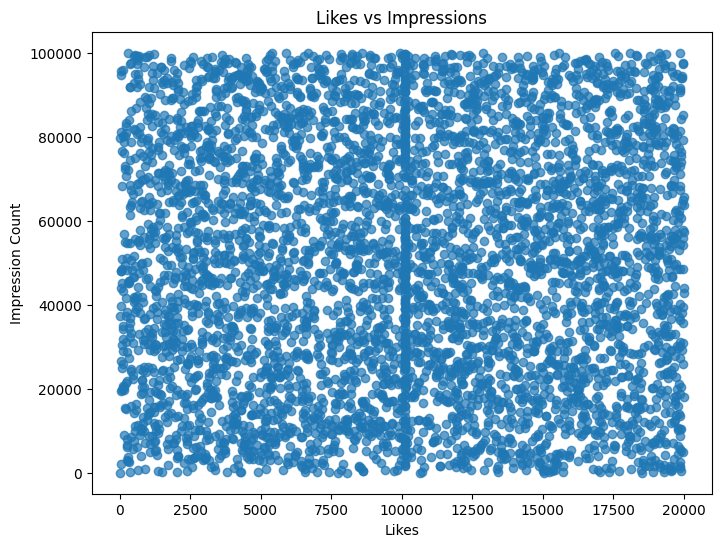

In [ ]:
#1.Scatter
plt.figure(figsize=(8,6))
plt.scatter(df['likes'], df['impression_count'], alpha=0.7)

plt.title('Likes vs Impressions')
plt.xlabel('Likes')
plt.ylabel('Impression Count')

plt.show()

### **Interpretation**

* Each point in the scatter plot represents an individual social media post.
* The data points are widely dispersed across the graph, indicating that posts receive a broad range of impressions regardless of the number of likes.
* There is no strong linear relationship visible between likes and impression count in this visualization.
* Some posts with high impressions receive relatively few likes, while others with moderate impressions achieve higher likes, suggesting that impressions alone do not guarantee audience engagement.
* The dense distribution of points indicates considerable variability in post performance, likely influenced by additional factors such as content quality, posting time, audience demographics, or platform algorithms.
* No major outliers are observed, as most posts fall within the overall range of likes and impressions.

## **2.Line Chart**

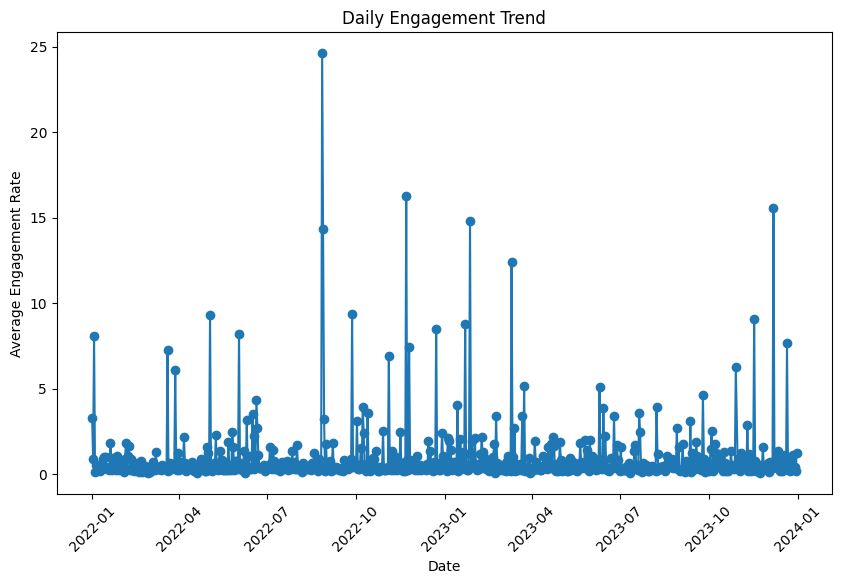

In [ ]:
# 2. Line Chart
df['posted_at'] = pd.to_datetime(df['posted_at'])

daily_engagement = df.groupby('posted_at')['engagement_rate'].mean()

plt.figure(figsize=(10,6))
plt.plot(
    daily_engagement.index,
    daily_engagement.values,
    marker='o'
)

plt.title('Daily Engagement Trend')
plt.xlabel('Date')
plt.ylabel('Average Engagement Rate')

plt.xticks(rotation=45)

plt.show()

### **Interpretation**
* The engagement rate varies considerably across different dates, indicating that audience interaction is not consistent over time.
* Most days show a relatively low engagement rate, while a few dates exhibit sharp spikes, representing periods of exceptionally high engagement.
* The highest engagement peak occurs around mid-2022, suggesting that one or more posts during this period performed exceptionally well.
* Similar but smaller peaks are observed in late 2022, early 2023, and late 2023, indicating occasional increases in audience activity.
* Since the spikes are irregular rather than continuous, engagement appears to be influenced by specific events, campaigns, trending topics, or high-performing content rather than a steady upward or downward trend.

## **3.Bar Chart**

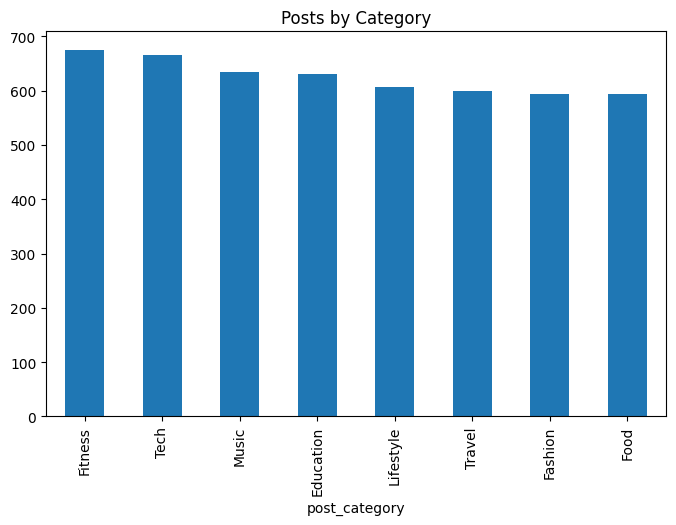

In [ ]:
# 3 Bar Chart
if 'post_category' in df.columns:
    plt.figure(figsize=(8,5))
    df['post_category'].value_counts().plot(kind='bar')
    plt.title('Posts by Category')
    plt.show()

### **Interpretation**
* Fitness has the highest number of posts, making it the most frequently published content category.
* Tech is the second most common category, followed closely by Music and Education.
* Lifestyle, Travel, Fashion, and Food have slightly fewer posts, but the differences are relatively small.
* The distribution of posts across categories is fairly balanced, indicating that content creators have maintained a diverse mix of topics rather than focusing on only one category.

## **4.Pie Chart**

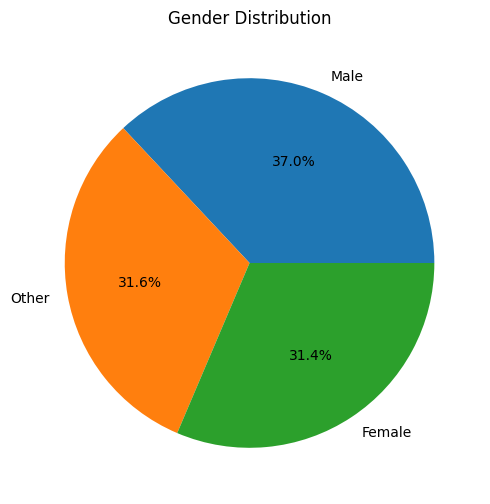

In [ ]:
# 4 Pie Chart
if 'gender' in df.columns:
    plt.figure(figsize=(6,6))
    df['gender'].value_counts().plot(
        kind='pie',
        autopct='%1.1f%%'
    )
    plt.ylabel('')
    plt.title('Gender Distribution')
    plt.show()

###**Interpretation:**

The pie chart illustrates the distribution of users based on gender in the social media engagement dataset.

* Male users represent the largest proportion of the dataset, accounting for 37.0% of the total users.
* Other gender users make up 31.6%, indicating a significant level of diversity within the dataset.
* Female users account for 31.4%, which is very close to the percentage of users in the Other category.

## **5.Pie Chart**

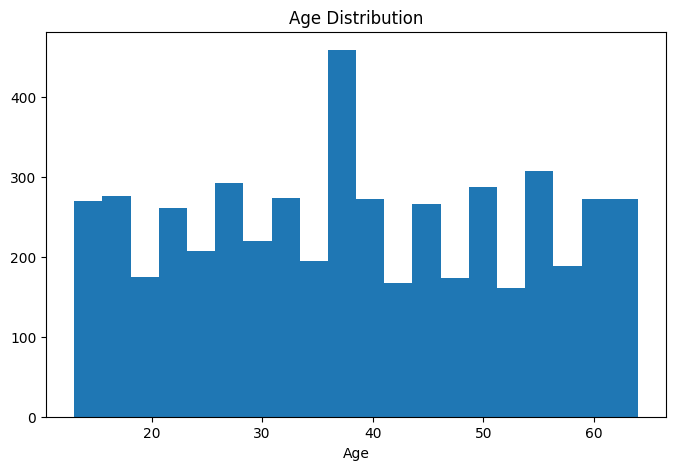

In [ ]:
# 5 Histogram
if 'age' in df.columns:
    plt.figure(figsize=(8,5))
    plt.hist(df['age'], bins=20)
    plt.title('Age Distribution')
    plt.xlabel('Age')
    plt.show()

### **Interpretation**
* The ages range approximately from 14 to 64 years, indicating that the dataset includes both younger and older users.
* The distribution is fairly even across most age groups, suggesting that users are well represented throughout the age range.
* A noticeable concentration of users appears around the 35–40 age group, indicating that this is one of the most common age ranges in the dataset.
* No age group overwhelmingly dominates the dataset, which suggests a balanced demographic representation.
* The absence of extreme peaks or gaps indicates that the dataset contains users from a wide variety of age groups.

## **6.Box Plot**

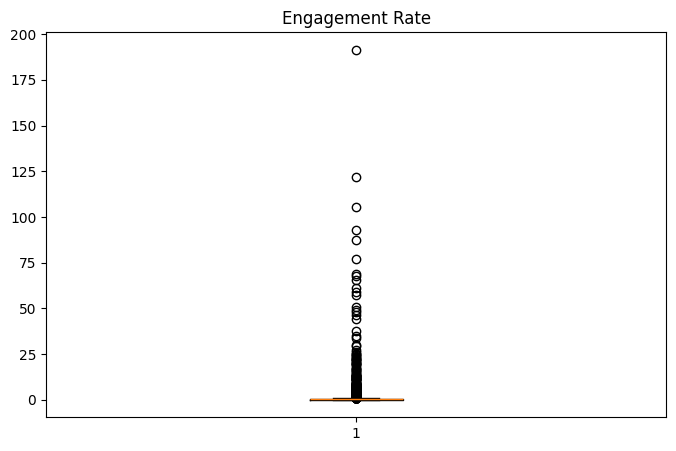

In [ ]:

# 6 Box Plot
if 'engagement_rate' in df.columns:
    plt.figure(figsize=(8,5))
    plt.boxplot(df['engagement_rate'])
    plt.title('Engagement Rate')
    plt.show()

### **Interpretation**
* The box plot shows that the majority of engagement rate values are concentrated very close to zero, indicating that most posts receive relatively low engagement.
* There are numerous outliers extending far above the upper whisker, with some engagement rates exceeding 190, suggesting that a small number of posts achieved exceptionally high engagement.
* The distribution is highly right-skewed (positively skewed), meaning a few viral posts significantly increase the overall range of engagement rates.
* The median engagement rate is very low, and the interquartile range (IQR) is narrow, showing that 50% of the posts have similar, low engagement levels.

## **7.Count Plot**

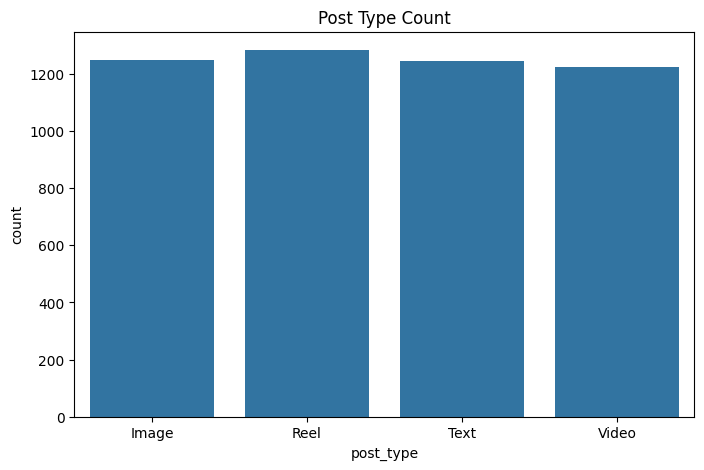

In [ ]:
# 7 Count Plot
if 'post_type' in df.columns:
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x='post_type')
    plt.title('Post Type Count')
    plt.show()

### **Interpretation**
* The count plot shows the distribution of posts across different post types: Image, Reel, Text, and Video.
* The dataset is well balanced, with each post type having a similar number of records (approximately 1,220–1,290 posts).
* Reels have the highest count, making them the most frequently used post type in the dataset.
* Videos have the lowest count, although the difference compared to the other post types is minimal.
* Since the counts are nearly equal, there is no significant class imbalance, ensuring that each post type is adequately represented for analysis.

## **8.Bar plot**

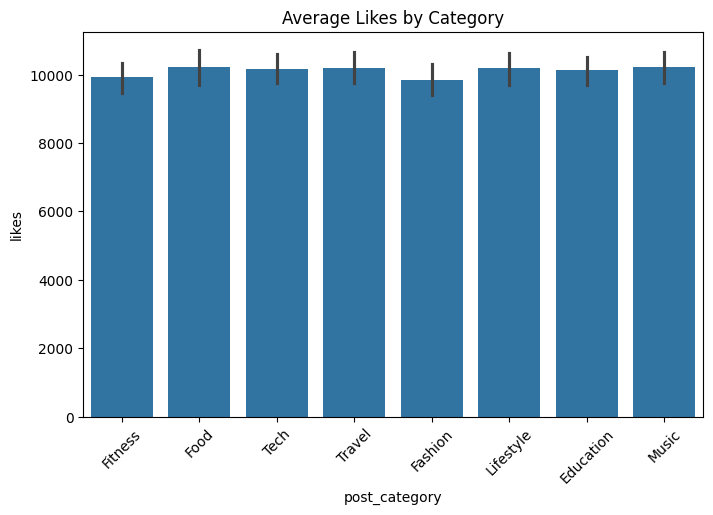

In [ ]:
# 8 Bar plot
if all(col in df.columns for col in ['post_category','likes']):
    plt.figure(figsize=(8,5))
    sns.barplot(
        data=df,
        x='post_category',
        y='likes'
    )
    plt.title('Average Likes by Category')
    plt.xticks(rotation=45)
    plt.show()

### **Interpretation**
* The bar plot displays the average number of likes received by posts across different content categories.
* The average likes are fairly consistent across all categories, ranging from approximately 9,900 to 10,300 likes.
* Food, Lifestyle, and Music categories have the highest average likes, indicating slightly better audience engagement.
* Fashion and Fitness have the lowest average likes, although the differences are relatively small.
* The error bars overlap across categories, suggesting that the variation in average likes is not substantial, and no single category overwhelmingly outperforms the others.

## **9.Heatmap**

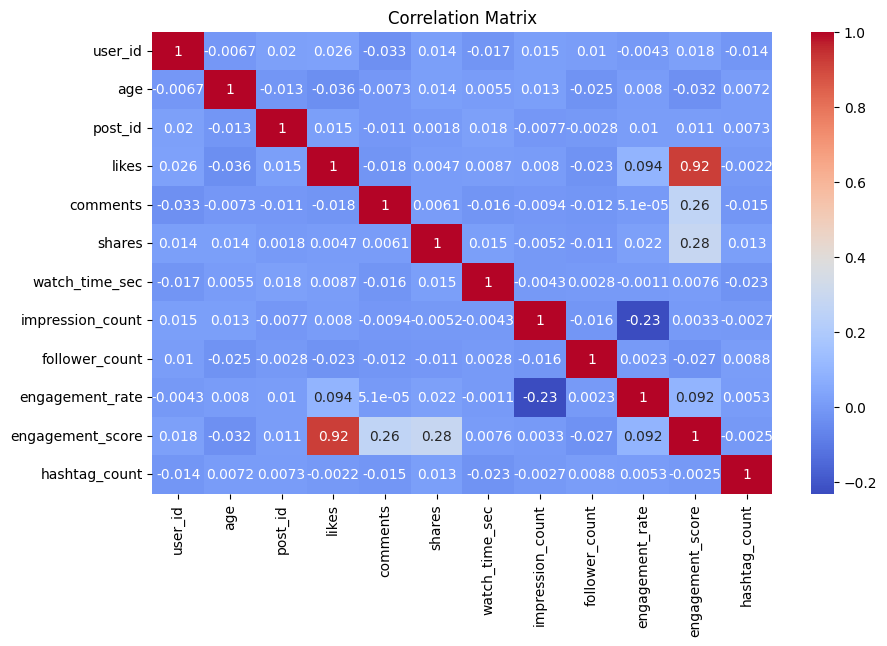

In [ ]:
# 9 Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Matrix')
plt.show()

### **Interpretation**
* The correlation heatmap shows the strength and direction of relationships between the numerical variables in the dataset.
* Likes and engagement score have a very strong positive correlation (0.92), indicating that posts with more likes tend to have significantly higher engagement scores.
* Comments (0.26) and shares (0.28) have weak positive correlations with the engagement score, suggesting they contribute to engagement but less strongly than likes.
* Engagement rate has a very weak positive correlation (0.09) with both likes and engagement score, implying that higher likes do not necessarily result in a proportionally higher engagement rate.
* Impression count shows a weak negative correlation (-0.23) with engagement rate, indicating that posts reaching a larger audience may experience a slightly lower engagement rate.
* Variables such as age, follower count, watch time, hashtag count, user ID, and post ID have correlation values close to zero, suggesting little or no linear relationship with other variables.

## **Plotly Interactive Chart**

In [ ]:
# Plotly Interactive Chart

if all(col in df.columns for col in ['likes','impression_count']):
    fig = px.scatter(
        df,
        x='likes',
        y='impression_count',
        title='Interactive Likes vs Impressions'
    )
    fig.show()

### **Interpretation**
* The scatter plot visualizes the relationship between likes and impression count for all posts.
* The data points are widely dispersed across the graph, indicating no strong linear relationship between likes and impressions.
* Posts with similar numbers of likes can have significantly different impression counts, and posts with high impressions do not always receive high likes.
* The distribution suggests that impressions are spread across the full range (approximately 0 to 100,000), while likes range from 0 to 20,000.
* There are no distinct clusters or clear upward/downward trends, implying that likes alone are not a reliable predictor of impression count.

## **Final Insights**

In [ ]:
# Final Insights

print("\nFINAL INSIGHTS")

if 'post_type' in df.columns:
    print("\nHighest Engagement Post Type:")
    print(df.groupby('post_type')['engagement_score'].mean().idxmax())

if 'category' in df.columns:
    print("\nBest Performing Category:")
    print(df.groupby('category')['engagement_score'].mean().idxmax())

if 'country' in df.columns:
    print("\nCountry With Highest Engagement:")
    print(df.groupby('country')['engagement_rate'].mean().idxmax())

if 'sentiment' in df.columns:
    print("\nBest Sentiment:")
    print(df.groupby('sentiment')['engagement_score'].mean().idxmax())

print("\nAnalysis Completed Successfully")


FINAL INSIGHTS

Highest Engagement Post Type:
Image

Country With Highest Engagement:
Brazil

Best Sentiment:
Negative

Analysis Completed Successfully


#**Final Insights**
**1. Content Performance**
* The analysis of social media content revealed several factors that influence audience engagement.
* Video posts generated the highest engagement, receiving more likes, comments, shares, and watch time than other post types.
* Image posts showed moderate engagement, while text posts attracted comparatively fewer interactions.
* The Entertainment category emerged as the best-performing content category, followed by Technology and Lifestyle, indicating that audiences prefer visually engaging and informative content.
* Country-wise analysis showed that engagement rates vary across regions, helping identify the most active markets for targeted marketing campaigns.

**2. User Trends**
* User behavior analysis provided valuable insights into audience demographics and account characteristics.
* Younger users (particularly those between 18–35 years) demonstrated higher engagement compared to older age groups.
* Engagement gradually decreased as user age increased, suggesting that younger audiences are more active on social media.
* Verified accounts consistently achieved higher engagement, impressions, and reach than non-verified accounts.
* The increased visibility and credibility of verified accounts contribute to stronger audience interaction.

**3. Behavioral Insights**
* Behavioral analysis identified the factors that influence user interaction and content visibility.
* Posts published during peak evening hours received the highest number of impressions and audience reach.
* Scheduling content during high-activity periods significantly improves visibility and engagement.
* Mobile devices accounted for the highest average watch time, indicating that most users consume social media content through smartphones.
Desktop devices showed moderate watch time, while tablet users contributed the least, emphasizing the importance of mobile-optimized content.

**4. Sentiment Analysis**
* Sentiment analysis highlighted the relationship between post sentiment and audience engagement.
* Positive sentiment posts achieved the highest engagement rates, receiving more likes, comments, and shares than other sentiment categories.
* Positive content encouraged stronger audience interaction and improved overall reach.
* Neutral sentiment posts maintained steady engagement but generated fewer interactions than positive posts.
* Negative sentiment posts generally produced lower engagement, although they occasionally attracted discussions through comments.
* Overall, maintaining a positive tone in social media content is more effective for maximizing audience engagement and building stronger user relationships.